<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/LED/AVANTES/LEDs_spectrum_measurements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spectrum of LEDs measured by spectrograph

Evgeny Kolonsky, 2024 - 2026

v.0.1.8

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.signal import find_peaks, peak_widths
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import pandas as pd
!wget -q https://raw.githubusercontent.com/tphlabs/data/refs/heads/main/Lab4_SP/spectrumplots.py -O spectrumplots.py -q
from spectrumplots import wavelength_to_color

Auxillary functions

In [2]:
def get_data(name):
  url = URL.format(**locals())
  waves, sample, dark = np.loadtxt(url, delimiter=';', skiprows=8, usecols=[0,1,2], unpack=True)
  counts = sample - dark
  return waves, counts

def get_peak(waves, counts, rel_height=0.5):
  '''
  gets vectors of waves vs counts
  optional parameter: relative height of the FWHM, by default 0.5
      the close to bottom the greater
  reutrns wl of the peak, fwhm and height of the peak
  '''
  peaks, _ = find_peaks(counts, width=3)
  widths, heights, _, _ = peak_widths(counts,peaks, rel_height=0.5)
  ix = np.argmax(heights)
  waves_spacing = np.mean(np.diff(waves))
  fwhms = widths * waves_spacing
  return waves[peaks[ix]], fwhms[ix], heights[ix]


def plot_spectrum(waves, counts, mode='dark'):

  if mode == 'dark':
    pltstyle = 'dark_background'
    fill_color = 'black'
    font_color = 'white'
  else:
    pltstyle = 'default'
    fill_color = 'white'
    font_color = 'black'


  visible_light = (350, 750) #nm
  norm = plt.Normalize(*visible_light)
  wl = np.arange(visible_light[0], visible_light[1] + 1, 2)
  colorlist = list(zip(norm(wl), [wavelength_to_color(w) for w in wl]))


  spectralmap = matplotlib.colors.LinearSegmentedColormap.from_list("spectrum", colorlist)
  plt.style.use(pltstyle)
  fig, axs = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)

  # Using the input waves and counts directly
  # wavelengths = spectrum['wave_length']
  # intensities = spectrum['counts']

  y = counts
  X, Y = np.meshgrid(waves, y)

  extent = (np.min(waves), np.max(waves), np.min(y), np.max(y))



  plt.imshow(X, clim=visible_light, extent=extent, cmap=spectralmap, aspect='auto')

  plt.xlabel('Wavelength (nm)')
  plt.xticks(np.arange(visible_light[0], visible_light[1]+10, 25))
  plt.ylabel('Intensity')

  plt.fill_between(waves, counts, max(counts), color=fill_color)
  plt.plot(waves, counts, color='gray', linewidth=1)

  plt.xlim(visible_light[0], visible_light[1])

  approximate = interp1d(waves, counts)

  wl_peak, width, height = get_peak(waves, counts, rel_height=0.5)
  note = fr'{wl_peak:.0f} $\pm$ {width/2:.0f} nm'

  # Improved annotation for readability
  plt.annotate(note, xy=(wl_peak, height), xytext=(10, 10),
                textcoords='offset points', color=font_color, fontsize=10,
                arrowprops=dict(facecolor=font_color, shrink=0.05, width=1, headwidth=5))
  plt.vlines(wl_peak, ymin=0, ymax=1, color='gray', # Extend to top of plot
              linestyle='--')
  plt.hlines(height, xmin=wl_peak-width/2, xmax=wl_peak+width/2, color='gray',
              linestyle='--')


  #plt.yscale('log')
  #plt.ylim(1e1, 1e5)
  #plt.legend(loc='upper left', fancybox=True,  fontsize='x-small')
  #plt.title(name.capitalize())
  plt.savefig(f'{name}.png', dpi=300)
  plt.show()

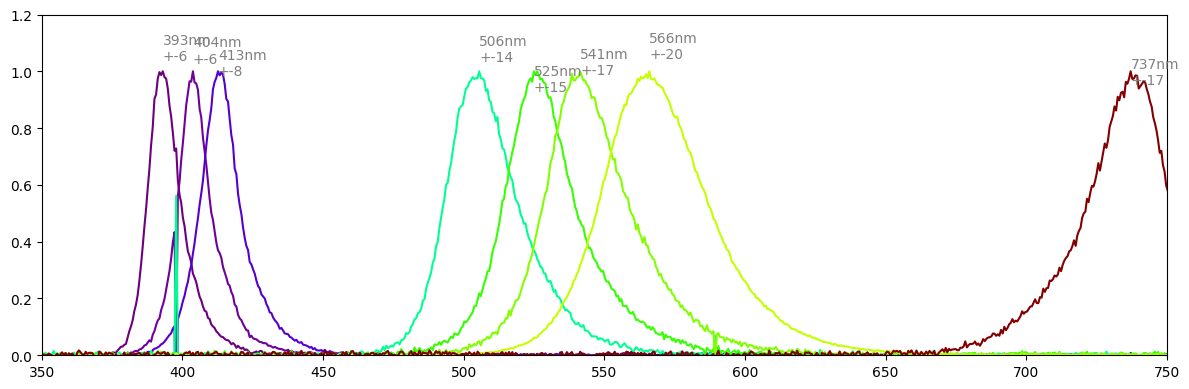

In [3]:
URL =  'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/LED/AVANTES/{name}.txt'

led_names = ['390-395', '400-410', '420-425', '500-510', '520-525', '540-550', '560-570', '730-730']

fig, ax = plt.subplots(1, 1, figsize=(12, 4), tight_layout=True)
for name in led_names:
  color = wavelength_to_color(int(name.split('-')[0]))
  waves, counts = get_data(name)
  counts /= np.max(counts) # normalize
  wl_peak, width, height = get_peak(waves, counts, rel_height=0.5)
  note = f'{wl_peak:.0f}nm\n+-{width/2:.0f}'
  plt.plot(waves, counts, color=color)
  # Improved annotation for readability
  plt.annotate(note, xy=(wl_peak, height*2.1),
                 color='gray', fontsize=10)
  #plt.vlines(wl_peak, ymin=height, ymax=1, color='gray', # Extend to top of plot
  #            linestyle='-')
  #plt.hlines(height, xmin=wl_peak-width/2, xmax=wl_peak+width/2, color='gray',
  #            linestyle='-')
  plt.xlim(350, 750)
  plt.ylim(0, 1.2)


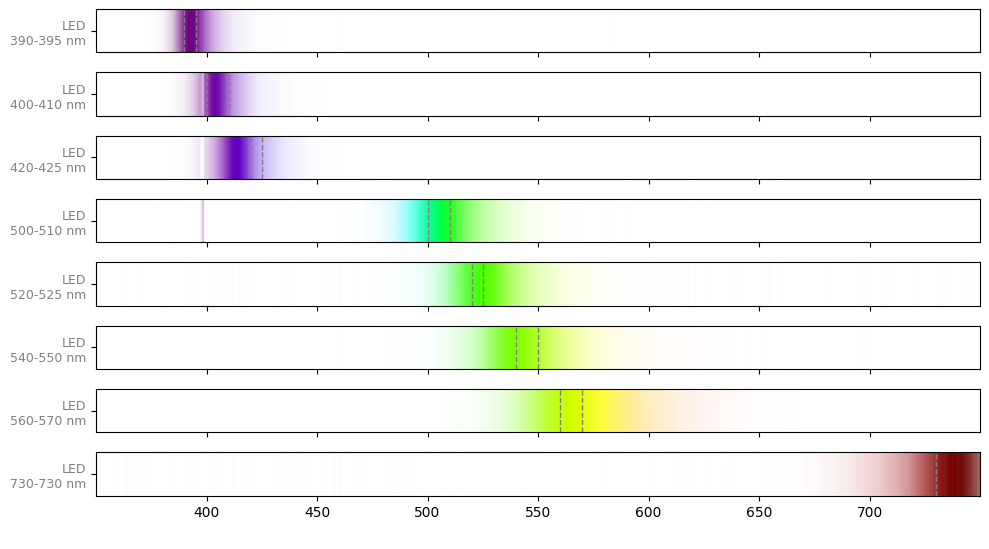

In [4]:
led_names = ['390-395', '400-410', '420-425', '500-510', '520-525', '540-550', '560-570', '730-730']

# Define the overall visible light range for consistent x-axis across plots
visible_light_range = (350, 750) # nm


num_diodes = len(led_names)
fig, axs = plt.subplots(num_diodes, 1, figsize=(10, num_diodes * 0.7), tight_layout=True)
plt.style.use('dark_background')

if num_diodes == 1:
    axs = [axs]

for i, led_name_str in enumerate(led_names):
    ax = axs[i]

    # Parse nominal start and end from the LED name string
    nominal_start_str, nominal_end_str = led_name_str.split('-')
    nominal_start = float(nominal_start_str)
    nominal_end = float(nominal_end_str)

    data_name = led_name_str # Use the full LED name for fetching data

    # Load measured data for this LED
    try:
        waves_measured, counts_measured = get_data(data_name)
    except Exception as e:
        print(f"Could not load data for {data_name}: {e}")
        ax.set_visible(False) # Hide axis if data not found
        continue

    # Generate a fine-grained array of wavelengths across the full visible spectrum
    wavelengths_full = np.linspace(visible_light_range[0], visible_light_range[1], 500)

    # Interpolate the measured counts onto the full wavelength range
    f_interp = interp1d(waves_measured, counts_measured, kind='linear', fill_value=0, bounds_error=False)
    measured_intensities_full = f_interp(wavelengths_full)

    # Normalize measured intensities to [0, 1] for use as an alpha channel
    max_intensity = np.max(measured_intensities_full)
    if max_intensity > 0:
        normalized_intensities = measured_intensities_full / max_intensity
    else:
        normalized_intensities = np.zeros_like(measured_intensities_full)

    # Clip normalized intensities to ensure they are within [0, 1] to prevent matplotlib warnings
    intensities_band = np.clip(normalized_intensities, 0, 1)

    # Get RGB colors for each wavelength in the full range (continuous spectrum)
    filtered_rgb_colors_band = np.array([matplotlib.colors.to_rgb(wavelength_to_color(w)) for w in wavelengths_full])

    # Prepare RGBA image data for imshow
    band_height = 30
    image_rgb_data_band = np.repeat(filtered_rgb_colors_band[np.newaxis, :, :], band_height, axis=0)
    image_alpha_data_band = np.repeat(intensities_band[np.newaxis, :], band_height, axis=0)

    image_rgba_band = np.zeros((band_height, len(wavelengths_full), 4))
    image_rgba_band[:, :, :3] = image_rgb_data_band
    image_rgba_band[:, :, 3] = image_alpha_data_band

    # Plotting with imshow
    ax.imshow(image_rgba_band,
               extent=(visible_light_range[0], visible_light_range[1], 0, 1),
               alpha = 1.0,
               cmap='gray',
               aspect='auto')

    # Add gray lines for nominal values
    ax.axvline(nominal_start, color='gray', linestyle='--', linewidth=1, alpha=1)
    ax.axvline(nominal_end, color='gray', linestyle='--', linewidth=1, alpha=1)


    # Set x-axis limits and labels
    ax.set_xlim(visible_light_range[0], visible_light_range[1])
    ax.set_xticks(np.arange(400, 701, 50))

    # Set y-tick label with nominal value
    ax.set_yticks([0.5])
    ax.set_yticklabels([f'LED\n{int(nominal_start)}-{int(nominal_end)} nm'], color='gray', fontsize=9)

    # Add x-axis label only to the bottom-most subplot
    if i == num_diodes - 1:
        ax.set_xlabel('Wavelength (nm)', color='white')
    else:
        ax.set_xticklabels([])

plt.show()